# Audio Classification Using CNN

In [1]:
import os
import random
import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)


In [2]:
DATASET_ROOT = r"./free-spoken-digit-dataset-1.0.9/recordings"

### Build File List

In [3]:
classes = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(
        os.path.join(DATASET_ROOT, d)
    )
    and not d.startswith("_")
])

class_to_idx = {
    c:i
    for i,c in enumerate(classes)
}

file_list = []
labels = []

for cls in classes:

    folder = os.path.join(
        DATASET_ROOT,
        cls
    )
    print(folder)

    wavs = [
        f for f in os.listdir(folder)
        if f.endswith(".wav")
    ]

    for wav in wavs:

        file_list.append(
            os.path.join(folder, wav)
        )

        labels.append(
            class_to_idx[cls]
        )

print("Classes:", len(classes))
print("Samples:", len(file_list))

Classes: 0
Samples: 0


### Step 1 Dataset Study

In [4]:
import os

file_list = []
labels = []

for file in os.listdir(DATASET_ROOT):

    if not file.endswith(".wav"):
        continue

    filepath = os.path.join(
        DATASET_ROOT,
        file
    )

    digit = int(
        file.split("_")[0]
    )

    file_list.append(
        filepath
    )

    labels.append(
        digit
    )

classes = [
    str(i)
    for i in range(10)
]

num_classes = 10

print(
    "Total Files:",
    len(file_list)
)

print(
    "Classes:",
    classes
)

Total Files: 2500
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [5]:
from collections import Counter

counter = Counter(labels)

stats_df = pd.DataFrame({
    "Digit": counter.keys(),
    "Count": counter.values()
})

stats_df = stats_df.sort_values(
    "Digit"
)

stats_df

,Digit,Count
0,0,250
1,1,250
2,2,250
3,3,250
4,4,250
5,5,250
6,6,250
7,7,250
8,8,250
9,9,250


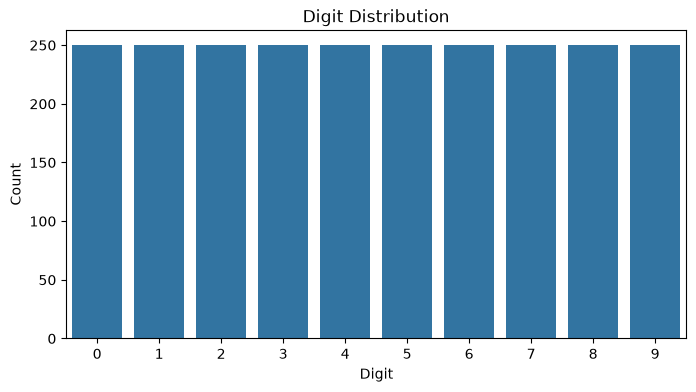

In [6]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=stats_df["Digit"],
    y=stats_df["Count"]
)

plt.title(
    "Digit Distribution"
)

plt.xlabel("Digit")
plt.ylabel("Count")

plt.show()

In [7]:
example_files = {}

for path,label in zip(
    file_list,
    labels
):

    if label not in example_files:

        example_files[label] = path

    if len(example_files) == 10:
        break

### Waveforms

c:\Tejeswar\embedUR_assignments\embedUR_AIML_assignments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


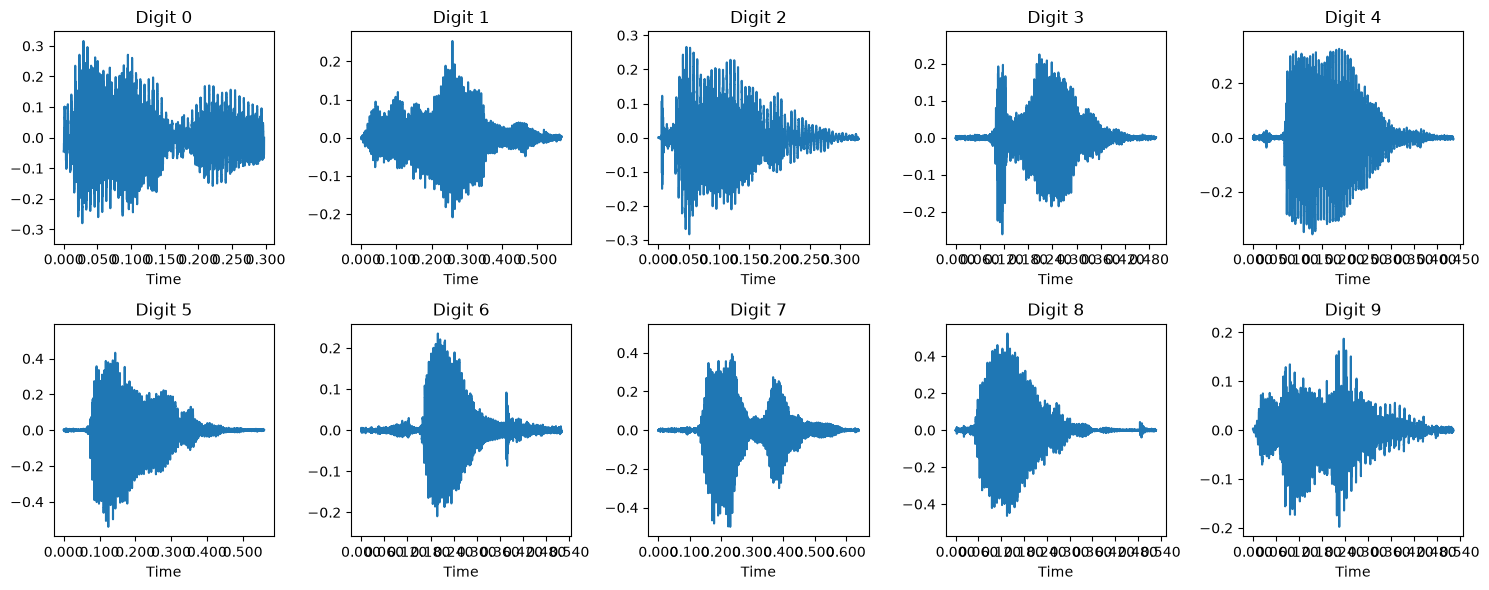

In [8]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(15,6)
)

axes = axes.flatten()

for digit,path in example_files.items():

    y,sr = librosa.load(
        path,
        sr=None
    )

    librosa.display.waveshow(
        y,
        sr=sr,
        ax=axes[digit]
    )

    axes[digit].set_title(
        f"Digit {digit}"
    )

plt.tight_layout()
plt.show()

### Spectrogram

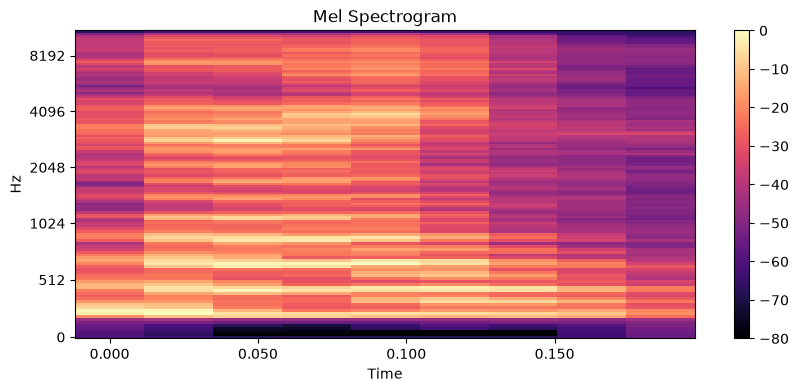

In [10]:
spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr
)

spec_db = librosa.power_to_db(
    spec,
    ref=np.max
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    spec_db,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

### Audio Preprocessor

In [11]:
class AudioPreprocessor:

    def __init__(
        self,
        sr=16000,
        n_mels=64,
        n_fft=1024,
        hop_length=512,
        target_duration=1.0
    ):

        self.sr = sr
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length

        self.target_samples = int(
            sr * target_duration
        )

    def load_and_resample(
        self,
        path
    ):

        y, sr = librosa.load(
            path,
            sr=self.sr,
            mono=True
        )

        return y

    def pad_or_truncate(
        self,
        y
    ):

        if len(y) > self.target_samples:

            y = y[
                :self.target_samples
            ]

        elif len(y) < self.target_samples:

            pad = (
                self.target_samples
                - len(y)
            )

            y = np.pad(
                y,
                (0,pad)
            )

        return y

    def extract_mel_spectrogram(
        self,
        y
    ):

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=self.sr,
            n_mels=self.n_mels,
            n_fft=self.n_fft,
            hop_length=self.hop_length
        )

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        mel_db = (
            mel_db
            - mel_db.mean()
        ) / (
            mel_db.std() + 1e-6
        )

        mel_db = np.expand_dims(
            mel_db,
            axis=0
        )

        return mel_db.astype(
            np.float32
        )

    def process(
        self,
        path
    ):

        y = self.load_and_resample(
            path
        )

        y = self.pad_or_truncate(
            y
        )

        mel = self.extract_mel_spectrogram(
            y
        )

        return mel

In [12]:
preprocessor = AudioPreprocessor()

### Dataset

In [13]:
class AudioDataset(Dataset):

    def __init__(
        self,
        file_list,
        labels,
        preprocessor,
        augment=None
    ):

        self.file_list = file_list
        self.labels = labels
        self.preprocessor = preprocessor
        self.augment = augment

    def __len__(self):

        return len(
            self.file_list
        )

    def __getitem__(
        self,
        idx
    ):

        spec = self.preprocessor.process(
            self.file_list[idx]
        )

        spec = torch.tensor(
            spec
        )

        if self.augment:

            spec = self.augment(
                spec
            )

        label = self.labels[idx]

        return spec, label

### Train Validation Test Split

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    file_list,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

### CNN

In [15]:
class AudioCNN(nn.Module):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                16,
                3,
                padding=1
            ),

            nn.BatchNorm2d(
                16
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                2
            ),

            nn.Conv2d(
                16,
                32,
                3,
                padding=1
            ),

            nn.BatchNorm2d(
                32
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                2
            ),

            nn.Conv2d(
                32,
                64,
                3,
                padding=1
            ),

            nn.BatchNorm2d(
                64
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1,1)
            )
        )

        self.classifier = nn.Linear(
            64,
            num_classes
        )

    def forward(
        self,
        x
    ):

        x = self.features(
            x
        )

        x = x.view(
            x.size(0),
            -1
        )

        return self.classifier(
            x
        )

### SpecAugment

In [16]:
class SpecAugment:

    def __init__(
        self,
        freq_mask_param=15,
        time_mask_param=35,
        num_freq_masks=2,
        num_time_masks=2
    ):

        self.F = freq_mask_param
        self.T = time_mask_param

        self.num_freq_masks = num_freq_masks
        self.num_time_masks = num_time_masks

    def freq_mask(
        self,
        spec
    ):

        _, n_mels, _ = spec.shape

        f = random.randint(
            0,
            self.F
        )

        f0 = random.randint(
            0,
            max(
                0,
                n_mels-f
            )
        )

        spec[
            :,
            f0:f0+f,
            :
        ] = 0

        return spec

    def time_mask(
        self,
        spec
    ):

        _, _, n_frames = spec.shape

        t = random.randint(
            0,
            self.T
        )

        t0 = random.randint(
            0,
            max(
                0,
                n_frames-t
            )
        )

        spec[
            :,
            :,
            t0:t0+t
        ] = 0

        return spec

    def __call__(
        self,
        spec
    ):

        spec = spec.clone()

        for _ in range(
            self.num_freq_masks
        ):

            spec = self.freq_mask(
                spec
            )

        for _ in range(
            self.num_time_masks
        ):

            spec = self.time_mask(
                spec
            )

        return spec

### Visualize SpecAugment

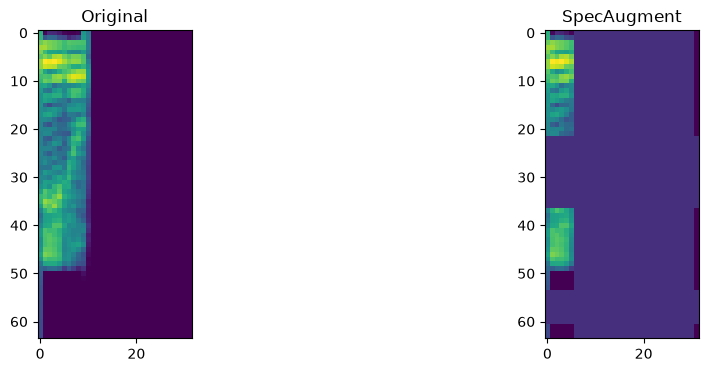

In [17]:
spec = preprocessor.process(
    file_list[0]
)

spec = torch.tensor(spec)

augment = SpecAugment()

aug_spec = augment(
    spec
)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(spec.squeeze())

plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(aug_spec.squeeze())

plt.title("SpecAugment")

plt.show()

### Training Loop

In [18]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model_aug = AudioCNN(
    num_classes=10
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_aug.parameters(),
    lr=0.001
)

In [20]:
augment = SpecAugment(
    freq_mask_param=15,
    time_mask_param=35,
    num_freq_masks=2,
    num_time_masks=2
)

train_dataset_aug = AudioDataset(
    X_train,
    y_train,
    preprocessor,
    augment=augment      # Part A
)

val_dataset = AudioDataset(
    X_val,
    y_val,
    preprocessor
)

test_dataset = AudioDataset(
    X_test,
    y_test,
    preprocessor
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=64,
    shuffle=True
)

val_loader_aug = DataLoader(
    val_dataset,
    batch_size=64
)

test_loader_aug = DataLoader(
    test_dataset,
    batch_size=64
)

In [21]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=10
):

    history = {
        "train_loss":[],
        "train_acc":[],
        "val_acc":[]
    }

    for epoch in range(
        epochs
    ):

        model.train()

        correct = 0
        total = 0
        loss_sum = 0

        for x,y in train_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            out = model(x)

            loss = criterion(
                out,
                y
            )

            loss.backward()

            optimizer.step()

            loss_sum += loss.item()

            pred = out.argmax(
                dim=1
            )

            correct += (
                pred==y
            ).sum().item()

            total += len(y)

        train_acc = correct/total

        history["train_loss"].append(
            loss_sum
        )

        history["train_acc"].append(
            train_acc
        )

        # validation
        model.eval()

        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for x, y in val_loader:

                x = x.to(device)
                y = y.to(device)

                out = model(x)

                pred = out.argmax(dim=1)

                val_correct += (
                    pred == y
                ).sum().item()

                val_total += len(y)

        val_acc = val_correct / val_total

        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return history

In [22]:
history_aug = train_model(
    model_aug,
    train_loader_aug,
    val_loader_aug,
    epochs=15
)

Epoch 1/15 | Train Acc: 0.1097 | Val Acc: 0.1253
Epoch 2/15 | Train Acc: 0.1149 | Val Acc: 0.1253
Epoch 3/15 | Train Acc: 0.1171 | Val Acc: 0.1440
Epoch 4/15 | Train Acc: 0.1263 | Val Acc: 0.1120
Epoch 5/15 | Train Acc: 0.1229 | Val Acc: 0.1493
Epoch 6/15 | Train Acc: 0.1314 | Val Acc: 0.1600
Epoch 7/15 | Train Acc: 0.1463 | Val Acc: 0.1840
Epoch 8/15 | Train Acc: 0.1269 | Val Acc: 0.1867
Epoch 9/15 | Train Acc: 0.1509 | Val Acc: 0.1733
Epoch 10/15 | Train Acc: 0.1400 | Val Acc: 0.2107
Epoch 11/15 | Train Acc: 0.1549 | Val Acc: 0.2267
Epoch 12/15 | Train Acc: 0.1651 | Val Acc: 0.1947
Epoch 13/15 | Train Acc: 0.1589 | Val Acc: 0.1813
Epoch 14/15 | Train Acc: 0.1880 | Val Acc: 0.3440
Epoch 15/15 | Train Acc: 0.1686 | Val Acc: 0.2640


In [23]:
print(history_aug)

{'train_loss': [64.75974702835083, 64.11723446846008, 64.03325653076172, 63.750412464141846, 63.668761014938354, 63.31639862060547, 63.073179721832275, 62.925105810165405, 62.59750008583069, 62.728869676589966, 62.28573799133301, 62.218331813812256, 61.84733271598816, 61.562429666519165, 61.59702515602112], 'train_acc': [0.10971428571428571, 0.11485714285714285, 0.11714285714285715, 0.12628571428571428, 0.12285714285714286, 0.13142857142857142, 0.1462857142857143, 0.12685714285714286, 0.15085714285714286, 0.14, 0.15485714285714286, 0.16514285714285715, 0.15885714285714286, 0.188, 0.16857142857142857], 'val_acc': [0.12533333333333332, 0.12533333333333332, 0.144, 0.112, 0.14933333333333335, 0.16, 0.184, 0.18666666666666668, 0.17333333333333334, 0.21066666666666667, 0.22666666666666666, 0.19466666666666665, 0.18133333333333335, 0.344, 0.264]}


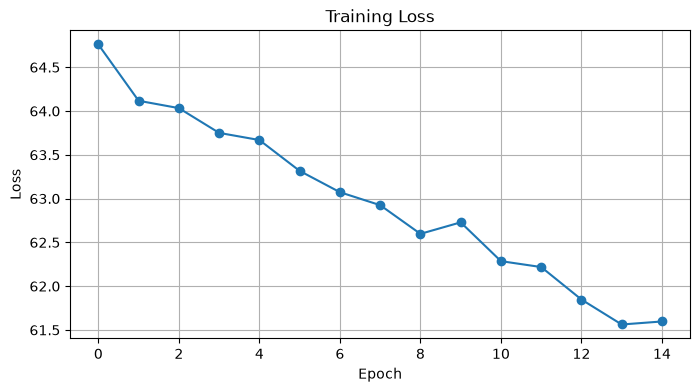

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(
    history_aug["train_loss"],
    marker="o"
)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

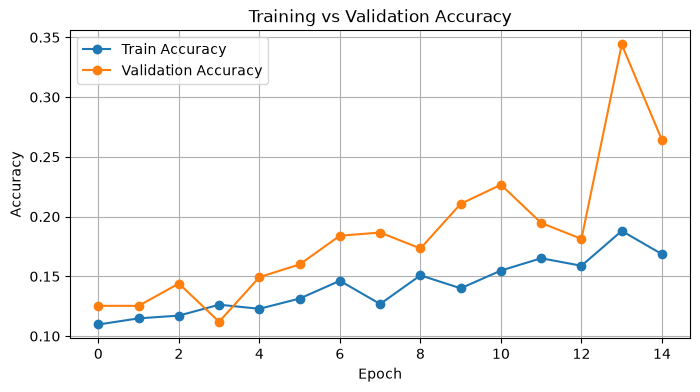

In [26]:
plt.figure(figsize=(8,4))

plt.plot(
    history_aug["train_acc"],
    label="Train Accuracy",
    marker="o"
)

plt.plot(
    history_aug["val_acc"],
    label="Validation Accuracy",
    marker="o"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

### Evaluate on Test Set

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

model_aug.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for x, y in test_loader_aug:

        x = x.to(device)

        outputs = model_aug(x)

        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            y.numpy()
        )

### Calculate Metrics

In [29]:
accuracy = accuracy_score(
    all_labels,
    all_preds
)

precision, recall, f1, _ = (
    precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro"
    )
)

print("===== TEST RESULTS =====")
print(f"Accuracy         : {accuracy:.4f}")
print(f"Macro Precision  : {precision:.4f}")
print(f"Macro Recall     : {recall:.4f}")
print(f"Macro F1 Score   : {f1:.4f}")

===== TEST RESULTS =====
Accuracy         : 0.2933
Macro Precision  : 0.3429
Macro Recall     : 0.2928
Macro F1 Score   : 0.2228


c:\Tejeswar\embedUR_assignments\embedUR_AIML_assignments\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Per-Class Metrics

In [30]:
print(
    classification_report(
        all_labels,
        all_preds
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        37
           1       1.00      0.08      0.15        37
           2       0.37      0.18      0.25        38
           3       0.22      0.34      0.27        38
           4       0.00      0.00      0.00        38
           5       0.23      0.57      0.33        37
           6       1.00      0.24      0.38        38
           7       0.00      0.00      0.00        37
           8       0.34      0.62      0.44        37
           9       0.27      0.89      0.41        38

    accuracy                           0.29       375
   macro avg       0.34      0.29      0.22       375
weighted avg       0.34      0.29      0.22       375



c:\Tejeswar\embedUR_assignments\embedUR_AIML_assignments\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Tejeswar\embedUR_assignments\embedUR_AIML_assignments\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Tejeswar\embedUR_assignments\embedUR_AIML_assignments\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

### Confusion Matrix

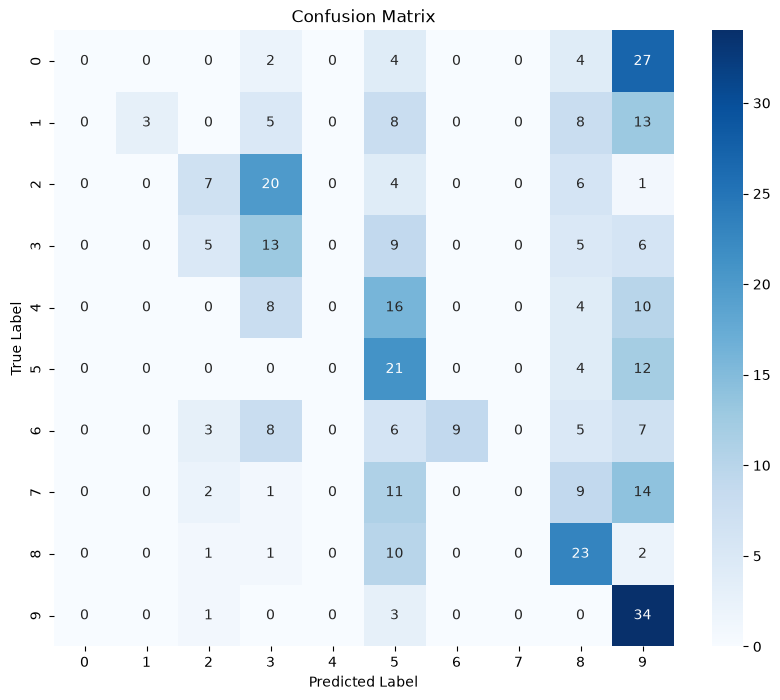

In [31]:
import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

### Summary Table

In [32]:
import pandas as pd

results_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results_df

,Metric,Value
0,Accuracy,0.293333
1,Macro Precision,0.342890
2,Macro Recall,0.292817
3,Macro F1,0.222774


### Find Correct Predictions

In [34]:
correct_examples = []

model_aug.eval()

with torch.no_grad():

    for x, y in test_loader_aug:

        x = x.to(device)

        outputs = model_aug(x)

        preds = outputs.argmax(dim=1)

        for i in range(len(y)):

            if preds[i].cpu() == y[i]:

                correct_examples.append(
                    (
                        x[i].cpu(),
                        y[i].item(),
                        preds[i].cpu().item()
                    )
                )

            if len(correct_examples) >= 3:
                break

        if len(correct_examples) >= 3:
            break

### Display 3 Correct Predictions

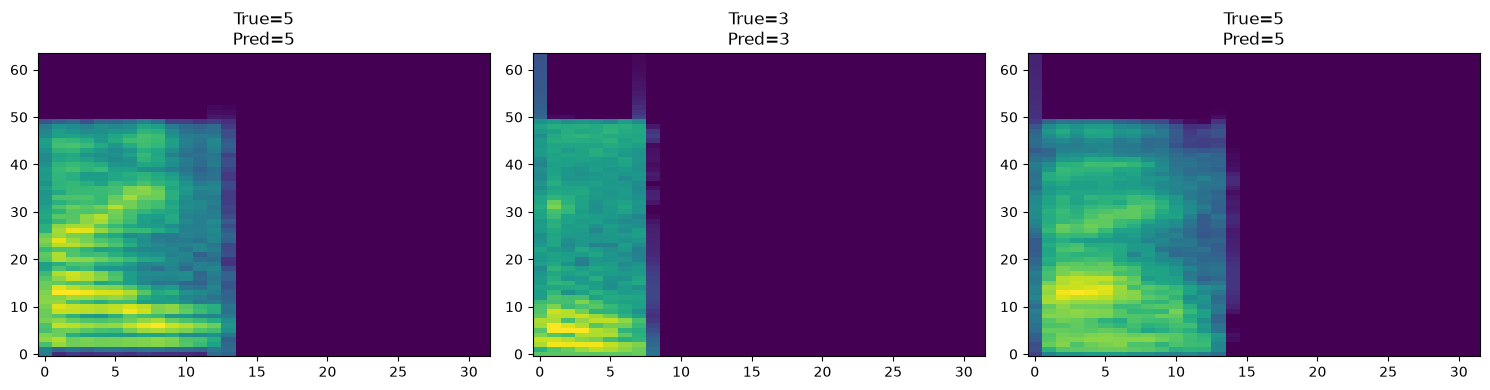

In [35]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,4)
)

for i, (spec, true_label, pred_label) in enumerate(correct_examples):

    axes[i].imshow(
        spec.squeeze().numpy(),
        aspect="auto",
        origin="lower"
    )

    axes[i].set_title(
        f"True={true_label}\nPred={pred_label}"
    )

plt.tight_layout()
plt.show()

### Find Incorrect Predictions

In [36]:
incorrect_examples = []

model_aug.eval()

with torch.no_grad():

    for x, y in test_loader_aug:

        x = x.to(device)

        outputs = model_aug(x)

        preds = outputs.argmax(dim=1)

        for i in range(len(y)):

            if preds[i].cpu() != y[i]:

                incorrect_examples.append(
                    (
                        x[i].cpu(),
                        y[i].item(),
                        preds[i].cpu().item()
                    )
                )

            if len(incorrect_examples) >= 3:
                break

        if len(incorrect_examples) >= 3:
            break

### Display 3 Incorrect Predictions

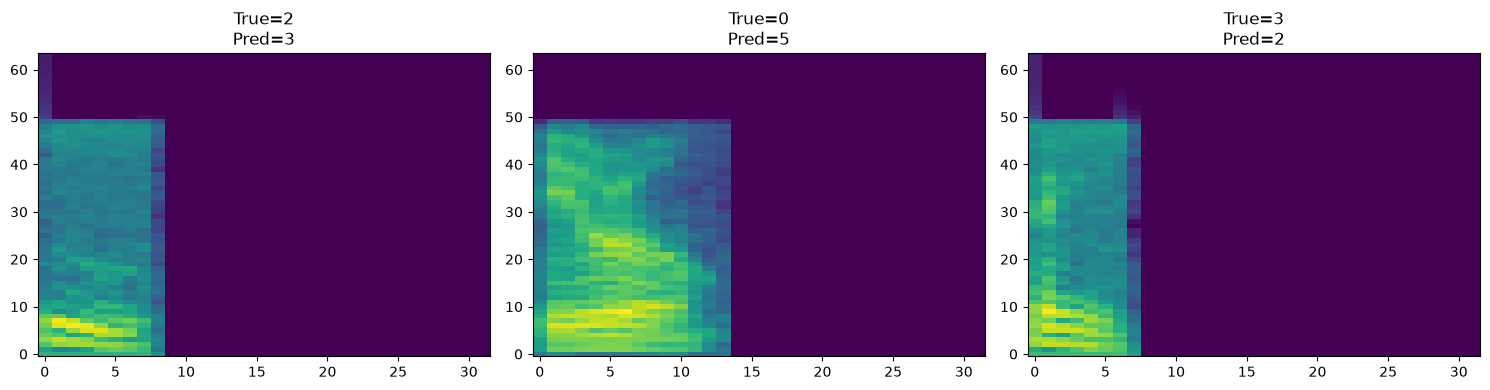

In [37]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,4)
)

for i, (spec, true_label, pred_label) in enumerate(incorrect_examples):

    axes[i].imshow(
        spec.squeeze().numpy(),
        aspect="auto",
        origin="lower"
    )

    axes[i].set_title(
        f"True={true_label}\nPred={pred_label}"
    )

plt.tight_layout()
plt.show()